In [14]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

%matplotlib inline

In [5]:
IRIS_DATA = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
             'iris/iris.data')

In [3]:
feature_dict = {
    i: label for i, label in enumerate(
        ['sepal_len', 'sepal_wid', 'petal_len', 'petal_wid'])}

In [7]:
df = pd.io.parsers.read_csv(
    filepath_or_buffer=IRIS_DATA, header=None, sep=',')
df.columns = ([lab for i, lab in sorted(feature_dict.items())] 
              + ['class label'])
df.dropna(how='all', inplace=True)
df.tail()

,sepal_len,sepal_wid,petal_len,petal_wid,class label
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [10]:
X = df[['sepal_len', 'sepal_wid', 'petal_len', 'petal_wid']].values
y = df['class label'].values

In [12]:
enc = LabelEncoder()
label_encoder = enc.fit(y)
y = label_encoder.transform(y) + 1
label_dict = {1: 'setosa', 2: 'versicolor', 3: 'virginica'}

/usr/local/lib/python3.6/site-packages/matplotlib/cbook/deprecation.py:107: MatplotlibDeprecationWarning: Passing one of 'on', 'true', 'off', 'false' as a boolean is deprecated; use an actual boolean (True/False) instead.
  warnings.warn(message, mplDeprecation, stacklevel=1)


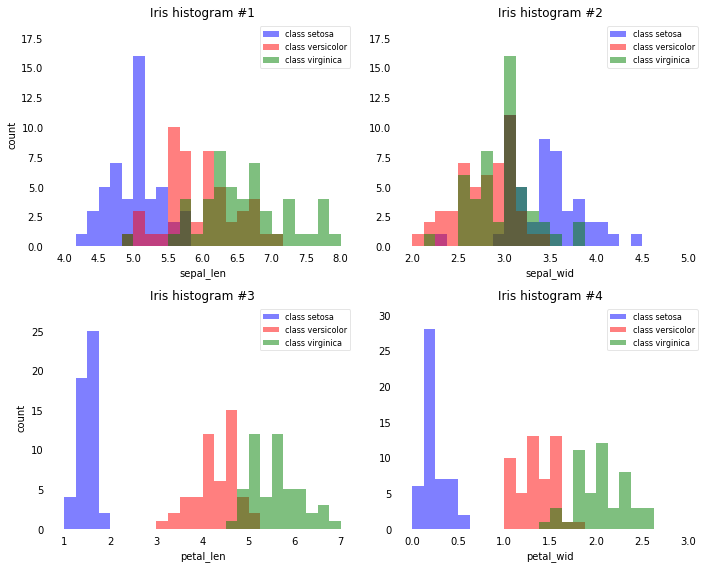

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

for ax, cnt in zip(axes.ravel(), range(4)):
    # set bin sizes
    min_b = math.floor(np.min(X[:, cnt]))
    max_b = math.ceil(np.max(X[:, cnt]))
    bins = np.linspace(min_b, max_b, 25)
    
    # plot
    for lab, col in zip(range(1, 4), ('blue', 'red', 'green')):
        ax.hist(X[y == lab, cnt], 
                color=col, 
                label='class %s' % label_dict[lab],
                bins=bins,
                alpha=0.5)
    ylims = ax.get_ylim()
    
    # Annotate
    leg = ax.legend(loc='upper right', fancybox=True, fontsize=8)
    leg.get_frame().set_alpha(0.5)
    ax.set_ylim([0, max(ylims) + 2])
    ax.set_xlabel(feature_dict[cnt])
    ax.set_title('Iris histogram #%s' % str(cnt + 1))
    
    # hide ticks
    ax.tick_params(axis='both', 
                   which='both', 
                   bottom='off', 
                   top='off', 
                   labelbottom='on', 
                   left='off', 
                   right='off', 
                   labelleft='on')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
axes[0][0].set_ylabel('count')
axes[1][0].set_ylabel('count')
fig.tight_layout()